# 🍇 Apollo AgriVerse - Grape Telemetry & Hydrogel Trigger Model

**Module:** Machine Learning (`06_ML`)  
**Target Crop:** Grapes (*Vitis vinifera*)  
**Source Dataset:** `02_Datasets/Processed/Grapes/Master_Grapes_Digital_Twin_Telemetry.csv`  
**Output Artifact:** `06_ML/models/grape_telemetry_trigger_model.pkl`  

---

## 📌 Purpose & Industrial Context
While static agronomy models predict seasonal yield, a Digital Twin requires **live state evaluation**. 

This notebook builds a telemetry-driven machine learning model that monitors real-time field microclimate, soil temperature/moisture, and mulching film degradation to predict the optimal **Smart Hydrogel Water Storage Percentage (`hydrogel_water_storage_pct`)**.

### Pipeline Workflow:
1. **Environment Setup & Data Ingestion**
2. **Exploratory Data Analysis (Telemetry Stream Dynamics)**
3. **Feature Engineering (Thermal-Moisture Stress Indices)**
4. **Data Scaling & Train-Test Split**
5. **Model Training & Evaluation (Gradient Boosting Regressor)**
6. **Artifact Serialization (`.pkl`) for Real-Time Backend API**

### Step 1: Environment Setup & Data Loading
We load the daily aggregated state vectors from `Master_Grapes_Digital_Twin_Telemetry.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

# File Paths
DATA_PATH = "../../02_Datasets/Processed/Grapes/Master_Grapes_Digital_Twin_Telemetry.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Load Data
df_telemetry = pd.read_csv(DATA_PATH)

print("=== TELEMETRY DATASET OVERVIEW ===")
print(f"Dimensions: {df_telemetry.shape[0]} rows × {df_telemetry.shape[1]} columns\n")
display(df_telemetry.head())

=== TELEMETRY DATASET OVERVIEW ===
Dimensions: 1000 rows × 24 columns



,farm_id,field_id,latitude,longitude,area_acres,soil_type,crop_type,installation_date,sowing_date,crop_age_days,...,canopy_cover_percent,expected_harvest_date,air_temp_c,humidity_pct,soil_moisture_pct,soil_temp_c,hydrogel_water_storage_pct,hydrogel_release_rate,mulch_degradation_pct,mulch_temp_reduction_c
0,F0001,FD0001,19.874540,73.685133,8.40,Loamy,Grapes,2026-01-01,2026-01-01,56,...,43.08,2026-08-01,26.965625,63.711250,51.935000,24.056875,50.348125,2.443750,52.205000,3.945625
1,F0002,FD0002,20.450714,74.041901,9.76,Loamy,Grapes,2026-01-01,2026-01-02,21,...,38.16,2026-08-02,26.940000,54.311111,52.241111,27.375556,50.225556,1.710000,35.113333,5.022222
2,F0003,FD0003,20.231994,74.372946,3.76,Red,Grapes,2026-01-01,2026-01-03,71,...,25.48,2026-08-03,28.227778,63.600000,38.712222,24.433333,56.020000,2.433333,51.998889,4.066667
3,F0004,FD0004,20.098658,74.232225,7.87,Loamy,Grapes,2026-01-01,2026-01-04,89,...,75.80,2026-08-04,22.756000,57.954000,34.732000,25.224000,31.400000,1.994000,41.728000,4.322000
4,F0005,FD0005,19.656019,74.306561,7.29,Loamy,Grapes,2026-01-01,2026-01-05,92,...,73.33,2026-08-05,30.743333,60.043333,57.901111,22.860000,67.345556,2.156667,45.532222,3.554444


### Step 2: Exploratory Data Analysis & Stress Relationships
We inspect how ambient air temperature, soil temperature, and mulching temperature reduction influence soil moisture and hydrogel behavior.

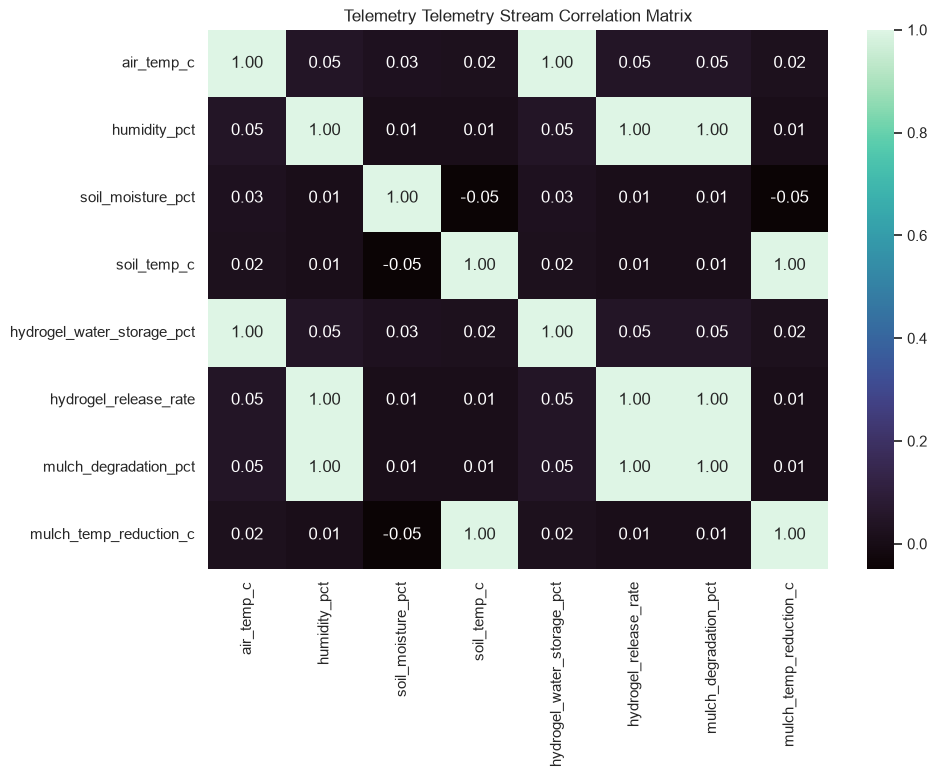

In [2]:
# Select key numerical features for telemetry dynamics
telemetry_cols = [
    'air_temp_c', 'humidity_pct', 'soil_moisture_pct', 
    'soil_temp_c', 'hydrogel_water_storage_pct', 
    'hydrogel_release_rate', 'mulch_degradation_pct', 'mulch_temp_reduction_c'
]

plt.figure(figsize=(10, 7))
sns.heatmap(df_telemetry[telemetry_cols].corr(), annot=True, cmap="mako", fmt=".2f")
plt.title("Telemetry Telemetry Stream Correlation Matrix")
plt.show()

### Step 3: Feature Engineering for Digital Twin State Vectors
We generate domain-specific physical interaction features:
1. **`thermal_gap`**: Difference between air temperature and soil temperature (buffers root zone thermal stress).
2. **`mulch_efficiency`**: Effective temperature suppression accounting for film degradation.
3. **`evapotranspiration_index`**: Ratio of ambient air temperature to relative humidity (proxy for soil moisture loss rate).

In [3]:
df_fe = df_telemetry.copy()
eps = 1e-5

# Feature 1: Thermal Gap
df_fe['thermal_gap'] = df_fe['air_temp_c'] - df_fe['soil_temp_c']

# Feature 2: Effective Mulch Efficiency
df_fe['effective_mulch_cooling'] = df_fe['mulch_temp_reduction_c'] * (1 - (df_fe['mulch_degradation_pct'] / 100))

# Feature 3: Proxy Evapotranspiration Index
df_fe['evapotranspiration_index'] = df_fe['air_temp_c'] / (df_fe['humidity_pct'] + eps)

print("Engineered Telemetry Features Added:")
display(df_fe[['thermal_gap', 'effective_mulch_cooling', 'evapotranspiration_index']].head())

Engineered Telemetry Features Added:


,thermal_gap,effective_mulch_cooling,evapotranspiration_index
0,2.908750,1.885811,0.423247
1,-0.435556,3.258753,0.496031
2,3.794444,1.952045,0.443833
3,-2.468000,2.518516,0.392656
4,7.883333,1.936027,0.512019


### Step 4: Preprocessing, Train-Test Split & Feature Scaling
We target `hydrogel_water_storage_pct` as our prediction variable to tell the backend API how much water buffer capacity the smart hydrogel layer should maintain given current microclimate stress.

In [5]:
# 1. Define Target Variable
y = df_fe['hydrogel_water_storage_pct']

# 2. Drop target column first
X_raw = df_fe.drop(columns=['hydrogel_water_storage_pct'], errors='ignore')

# 3. Keep ONLY numerical features for the ML model (removes farm_id, farmer_name, dates, strings)
X = X_raw.select_dtypes(include=[np.number])

# 4. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale Numerical Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Save Scaler
scaler_path = os.path.join(MODEL_DIR, "grape_telemetry_scaler.pkl")
joblib.dump(scaler, scaler_path)

print(f"Features used in training: {list(X.columns)}")
print(f"Train Set Shape: {X_train.shape}")
print(f"Test Set Shape : {X_test.shape}")
print(f"Telemetry Scaler Saved: {scaler_path}")

Features used in training: ['latitude', 'longitude', 'area_acres', 'crop_age_days', 'plant_height_cm', 'leaf_area_index', 'chlorophyll_index', 'canopy_cover_percent', 'air_temp_c', 'humidity_pct', 'soil_moisture_pct', 'soil_temp_c', 'hydrogel_release_rate', 'mulch_degradation_pct', 'mulch_temp_reduction_c', 'thermal_gap', 'effective_mulch_cooling', 'evapotranspiration_index']
Train Set Shape: (800, 18)
Test Set Shape : (200, 18)
Telemetry Scaler Saved: ../models\grape_telemetry_scaler.pkl


### Step 5: Model Training & Evaluation
We train a **Gradient Boosting Regressor** tuned for non-linear microclimate feedback loops.

In [6]:
# Initialize and Train Model
telemetry_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=4, random_state=42)
telemetry_model.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred = telemetry_model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== TELEMETRY MODEL PERFORMANCE ===")
print(f"Test RMSE : {rmse:.4f} %")
print(f"Test MAE  : {mae:.4f} %")
print(f"Test R²   : {r2:.4f}")

# Save Model
model_path = os.path.join(MODEL_DIR, "grape_telemetry_trigger_model.pkl")
joblib.dump(telemetry_model, model_path)
print(f"Model successfully saved to: {model_path}")

=== TELEMETRY MODEL PERFORMANCE ===
Test RMSE : 0.9484 %
Test MAE  : 0.1456 %
Test R²   : 0.9900
Model successfully saved to: ../models\grape_telemetry_trigger_model.pkl
